In [1]:
try:
    import gymnasium as gym
except ImportError:
    import gym

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt


In [2]:
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(PolicyNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, state):
        return self.net(state)

class CuriosityModel(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(CuriosityModel, self).__init__()
        self.predictor = nn.Sequential(
            nn.Linear(state_dim + action_dim, 128),
            nn.ReLU(),
            nn.Linear(128, state_dim)
        )

    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)
        return self.predictor(x)


In [3]:
env = gym.make("CartPole-v1")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

policy = PolicyNetwork(state_dim, action_dim)
curiosity = CuriosityModel(state_dim, 1)
optimizer = optim.Adam(list(policy.parameters()) + list(curiosity.parameters()), lr=0.001)
loss_fn = nn.MSELoss()


In [4]:
def train_agent(episodes=500):
    total_rewards = []

    for episode in range(episodes):
        state, _ = env.reset()
        episode_reward = 0
        done = False

        while not done:
            state_tensor = torch.FloatTensor(state)
            action_probs = policy(state_tensor)
            action = torch.multinomial(action_probs, 1).item()

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            action_tensor = torch.FloatTensor([action])
            pred_next = curiosity(state_tensor.unsqueeze(0), action_tensor.unsqueeze(0))
            target_next = torch.FloatTensor(next_state).unsqueeze(0)

            curiosity_reward = torch.mean((pred_next - target_next) ** 2).item()
            total_reward = reward + curiosity_reward * 0.01

            loss = loss_fn(pred_next, target_next)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            episode_reward += total_reward
            state = next_state

        total_rewards.append(episode_reward)

    return total_rewards


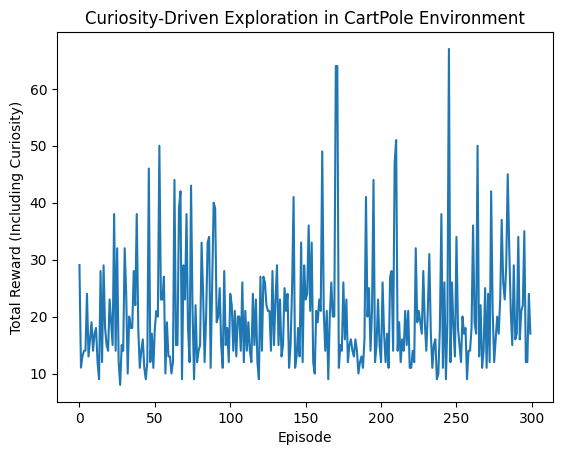

In [5]:
rewards = train_agent(300)
plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward (Including Curiosity)")
plt.title("Curiosity-Driven Exploration in CartPole Environment")
plt.show()
